# From a CMB *map* to a power spectrum — spherical harmonic decomposition

The capstone. We don't start from a pre-binned spectrum — we start from a **sky map** and
compute the power spectrum ourselves, by **spherical-harmonic decomposition**, then fit a
cosmology to it. The core map is a synthetic Nside-2048 sky (so it runs offline); at the end
we run the same pipeline on the *real* Planck SMICA map.

> The map is 50 million pixels (~400 MB), regenerated from a seed rather than shipped. The
> committed data product is the small bandpowers CSV — the spectrum we measure off the map.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, matplotlib.pyplot as plt, healpy as hp
from scripts.powerspectrum import generate_cmb_map, map_to_alm, cl_from_alm, pixel_window, bin_spectrum
from scripts.cosmofit import theory_cl_tt
LMAX, NSIDE = 2000, 2048

## 1. Make a sky to analyze

Draw a Gaussian CMB realization from a theory C_ℓ (CAMB) with `synfast`. This is our
"observation": a temperature on every pixel of the sphere.

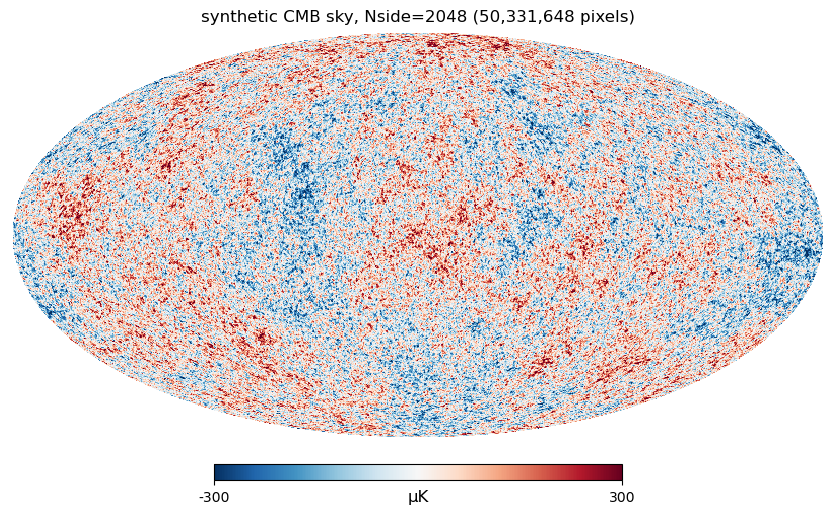

In [2]:
cl_in = theory_cl_tt(69.0, 0.118, 2.05, lmax=LMAX)[:LMAX+1]
m = generate_cmb_map(cl_in, NSIDE, LMAX, seed=17)
hp.mollview(m, title=f"synthetic CMB sky, Nside={NSIDE} ({m.size:,} pixels)", unit="μK",
            cmap="RdBu_r", min=-300, max=300); plt.show()

## 2. The spherical harmonic decomposition

Any function on the sphere expands in spherical harmonics $Y_{\ell m}$:

$$T(\hat n)=\sum_{\ell m} a_{\ell m}\,Y_{\ell m}(\hat n),\qquad
a_{\ell m}=\int T(\hat n)\,Y^*_{\ell m}(\hat n)\,d\Omega .$$

`healpy.map2alm` evaluates that integral. The **angular power spectrum** is the variance of
the coefficients at each scale $\ell$:

$$\hat C_\ell=\frac{1}{2\ell+1}\sum_{m=-\ell}^{\ell}|a_{\ell m}|^2 .$$

We compute that m-sum **by hand** in `cl_from_alm` (HEALPix stores only $m\ge0$, so for a real
map it's $|a_{\ell0}|^2+2\sum_{m\ge1}|a_{\ell m}|^2$) and check it against `healpy.alm2cl`.

In [3]:
alm = map_to_alm(m, LMAX)
print("a_lm computed:", alm.size, "coefficients up to l =", LMAX)
cl_ours = cl_from_alm(alm, LMAX)
print("our cl_from_alm vs healpy.alm2cl  — max abs diff:", np.max(np.abs(cl_ours - hp.alm2cl(alm))))

a_lm computed: 2003001 coefficients up to l = 2000
our cl_from_alm vs healpy.alm2cl  — max abs diff: 1.1368683772161603e-13


## 3. Correct the pixel window and bin → recover the spectrum

Finite pixels smooth the map (the pixel window $w_\ell$); divide it out. Then bin into
bandpowers. The recovered spectrum should sit on the input theory — acoustic peaks and all.

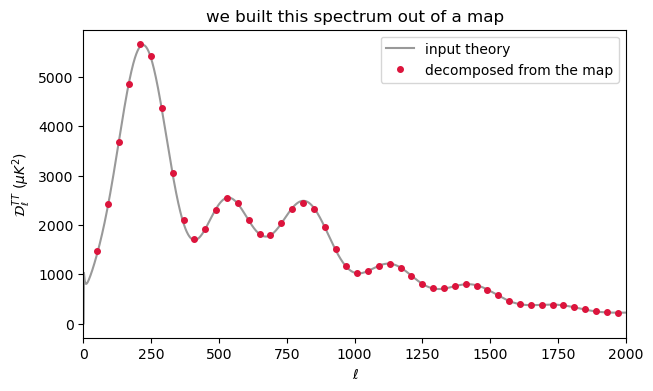

In [4]:
cl_rec = cl_ours / pixel_window(NSIDE, LMAX)**2
ell = np.arange(LMAX+1)
l_eff, cb = bin_spectrum(ell, cl_rec, 30, LMAX, 40)
D = lambda l, cl: l*(l+1)*cl/(2*np.pi)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(ell, D(ell, cl_in), "-", color="0.6", label="input theory")
ax.plot(l_eff, D(l_eff, cb), "o", ms=4, color="crimson", label="decomposed from the map")
ax.set_xlim(0,LMAX); ax.set_xlabel("ℓ"); ax.set_ylabel(r"$\mathcal{D}_\ell^{TT}\ (\mu K^2)$")
ax.legend(); ax.set_title("we built this spectrum out of a map"); plt.show()

## 4. Real skies are masked — and that needs NaMaster

The Galaxy contaminates part of the sky, so we mask it. Masking couples multipoles; dividing
by f_sky = ⟨mask²⟩ is only a first correction. **NaMaster** does the rigorous mode-coupling
("MASTER") deconvolution — our external answer key. Here on a Galactic-cut sky:

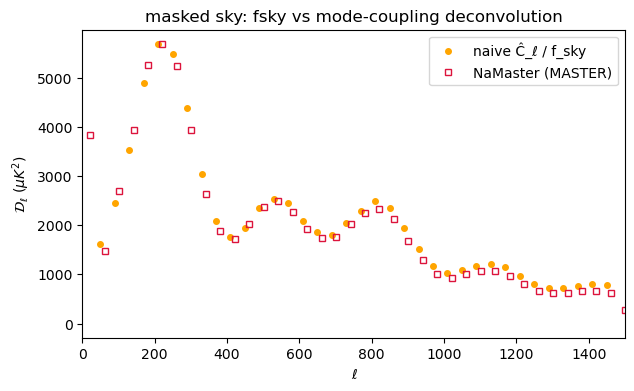

In [5]:
import pymaster as nmt
from scripts.powerspectrum import pseudo_cl, namaster_bandpowers
ns2, lm2 = 1024, 1500
m2 = generate_cmb_map(theory_cl_tt(69.0,0.118,2.05,lmax=lm2), ns2, lm2, seed=17)
b = 90 - np.degrees(hp.pix2ang(ns2, np.arange(hp.nside2npix(ns2)))[0])
mask = nmt.mask_apodization((np.abs(b)>15).astype(float), 2.0, "C2")
ln, cbn = bin_spectrum(np.arange(lm2+1), pseudo_cl(m2, mask, lm2, ns2), 30, lm2, 40)
lm, cbm = namaster_bandpowers(m2, mask, ns2, 40)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(ln, D(ln,cbn), "o", color="orange", ms=4, label="naive Ĉ_ℓ / f_sky")
ax.plot(lm, D(lm,cbm), "s", mfc="none", color="crimson", ms=4, label="NaMaster (MASTER)")
ax.set_xlim(0,lm2); ax.set_xlabel("ℓ"); ax.set_ylabel(r"$\mathcal{D}_\ell\ (\mu K^2)$")
ax.legend(); ax.set_title("masked sky: fsky vs mode-coupling deconvolution"); plt.show()

## 5. Fit a cosmology to the map-derived spectrum

Finally, fit ΛCDM (CAMB) to the bandpowers we measured off the map, with cosmic-variance
errors. We injected H₀ = 69; we should get it back.

In [6]:
from scripts.cosmofit import fit_cosmology
bp = np.loadtxt("data/synthetic/bandpowers_tt.csv", delimiter=",", skiprows=1)
sel = bp[:,0] < 1500
fit = fit_cosmology(bp[sel,0], bp[sel,1], bp[sel,2], lmax=1800)
print(f"recovered H0={fit['H0']:.2f} (injected 69.0), omch2={fit['omch2']:.4f}, As={fit['As']:.3f}")
print("the CMB's early-Universe H0 ~ 67-69 vs demo 05's local 74.8 = the Hubble tension")

recovered H0=69.19 (injected 69.0), omch2=0.1169, As=2.049
the CMB's early-Universe H0 ~ 67-69 vs demo 05's local 74.8 = the Hubble tension


## 6. The real sky

The same pipeline on the **real** Planck SMICA map (downgraded to Nside 256). Its first
acoustic peak emerges from genuine data — no theory input, just the decomposition.

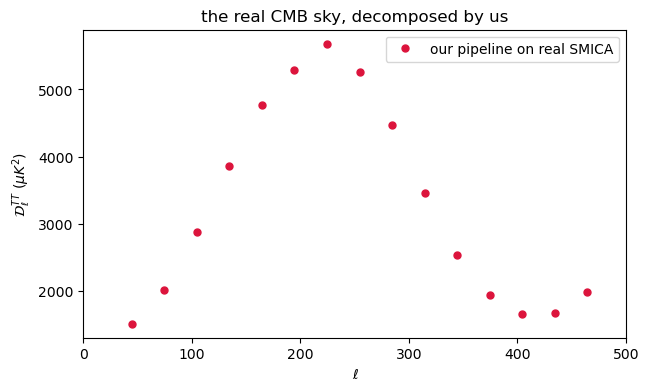

In [7]:
I = hp.read_map("data/real/planck_smica_I_nside256.fits")
msk = hp.read_map("data/real/planck_smica_mask_nside256.fits")
clr = pseudo_cl(I, nmt.mask_apodization(msk, 5.0, "C2"), 500, 256)
lr, cbr = bin_spectrum(np.arange(501), clr, 30, 500, 30)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(lr, D(lr,cbr), "o", color="crimson", ms=5, label="our pipeline on real SMICA")
ax.set_xlim(0,500); ax.set_xlabel("ℓ"); ax.set_ylabel(r"$\mathcal{D}_\ell^{TT}\ (\mu K^2)$")
ax.legend(); ax.set_title("the real CMB sky, decomposed by us"); plt.show()

## Result

We went from a **sky map** to a **power spectrum** by spherical-harmonic decomposition
(`map2alm` → $\hat C_\ell=\frac1{2\ell+1}\sum_m|a_{\ell m}|^2$ → bin), validated the
estimator against `healpy.alm2cl` and the masked pipeline against **NaMaster**, fit ΛCDM and
recovered the injected cosmology, and reproduced the first acoustic peak from the **real**
Planck map. See `notes/` — including a catalog of the intermediate problems this took.